# K-Means Cluster Analysis

*Unsupervised clustering of taxa based on CAT climate rating trajectories.*

**Conventions**
- Paths are relative to the notebook location.
- Unless stated otherwise, data are treated as read-only and the notebook writes outputs to `../data/`.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42

# Plot defaults (kept minimal)
plt.rcParams.update({'figure.dpi': 120})


## 2. Load data

In [2]:
csv_path = '../data/FullJoin3_with_climate_ratings-proofed.csv'
df = pd.read_csv(csv_path)


## 3. Data preparation (year mapping)

In [3]:
# We explicitly map the CSV columns to the CORRECT years (2050/2090)
column_map = {
    'climate_rating_current_sheet': 'Current',
    'climate_rating_emissions_limited_2050': '2050',         # WAS 2040
    'climate_rating_business_as_usual_2090': '2090',         # WAS 2080
    'climate_rating_bau_plus_1degree_2090': '2090_Plus1'    # WAS 2080
}

# Check if columns exist before renaming to avoid KeyErrors
# (This handles cases where the CSV might already have short names)
existing_cols = set(df.columns)
rename_dict = {k: v for k, v in column_map.items() if k in existing_cols}

df_analysis = df.rename(columns=rename_dict).copy()

# Select features for clustering
features = ['Current', '2050', '2090', '2090_Plus1']
X = df_analysis[features]

# Impute missing values (Mean strategy)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Scale the data (Crucial for K-Means to treat all years equally)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


## 4. K-Means clustering

In [4]:
# n_clusters=4 aligns with your standard taxonomy
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_analysis['Cluster_ID'] = clusters


## 5. Intelligent Cluster Labeling

In [5]:
# We analyze the centroids to assign meaningful names dynamically
centroid_means = df_analysis.groupby('Cluster_ID')[features].mean()

# Define Logic based on the CORRECT 2050/2090 timeline: 
# - Resilient: High rating in 2090 (> 7.5)
# - Highly Vulnerable: Low rating in 2090 (< 4.5)
# - Moderately Vulnerable: The middle ground
# - Climate Beneficiary: Rating improves from Current to 2090

cluster_labels = {}
for cluster_id, row in centroid_means.iterrows():
    rating_2090 = row['2090']
    decline = row['Current'] - row['2090']
    
    if rating_2090 >= 8.0:
        label = "Climate Resilient"
    elif rating_2090 <= 4.0:
        label = "Highly Vulnerable"
    elif decline < -0.5: 
        label = "Climate Beneficiary"
    else:
        label = "Moderately Vulnerable"
        
    cluster_labels[cluster_id] = label

# Apply the labels
df_analysis['Cluster_Label'] = df_analysis['Cluster_ID'].map(cluster_labels)


## 6. Export results

In [7]:
# Save the clustered data
output_csv = '../data/UBCBG_Clustered_Analysis.csv'
df_analysis.to_csv(output_csv, index=False)

# Save the Analysis JSON
analysis_json = {
    "cluster_definitions": cluster_labels,
    "centroids": centroid_means.to_dict(orient='index')
}

with open('climate_cluster_analysis.json', 'w') as f:
    # Custom encoder for numpy types
    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, (np.integer, np.floating)): return float(obj)
            return super().default(obj)
    json.dump(analysis_json, f, indent=2, cls=NumpyEncoder)


## 7. Visualization (Sanity Check)

Cluster Analysis Complete (Years corrected to 2050/2090).

Identified Groups:
Cluster_Label
Moderately Vulnerable    8056
Climate Resilient        5818
Highly Vulnerable        2288
Name: count, dtype: int64

Centroid Profiles:
              Current       2050       2090  2090_Plus1
Cluster_ID                                             
0            9.785056  10.317523  10.763599   10.230190
1           10.709202   9.842312   6.983287    5.567637
2            9.490822   5.817745   3.649476    2.952360
3            4.681188   7.304950   8.855446    9.055446


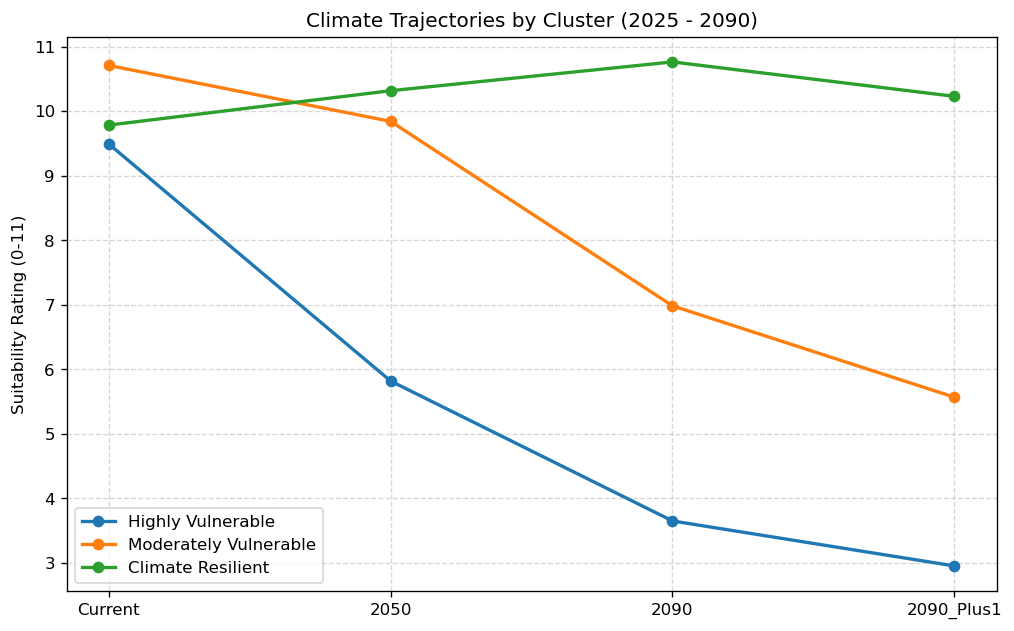

In [8]:
print("Cluster Analysis Complete (Years corrected to 2050/2090).")
print("\nIdentified Groups:")
print(df_analysis['Cluster_Label'].value_counts())
print("\nCentroid Profiles:")
print(centroid_means)

# Plot the Trajectories
plt.figure(figsize=(10, 6))
for label in df_analysis['Cluster_Label'].unique():
    subset_id = df_analysis[df_analysis['Cluster_Label']==label]['Cluster_ID'].iloc[0]
    subset_data = centroid_means.loc[subset_id]
    plt.plot(features, subset_data, marker='o', linewidth=2, label=label)

plt.title("Climate Trajectories by Cluster (2025 - 2090)")
plt.ylabel("Suitability Rating (0-11)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()
